In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.DataFrame(np.random.randint(1,100,(5,5)))

In [3]:
df.iloc[1,4] = np.nan
df.iloc[2,3] = np.nan
df.iloc[1,2] = np.nan
df.iloc[2,4] = np.nan


In [4]:
df

,0,1,2,3,4
0,4,37,88.0,30.0,92.0
1,86,2,NaN,66.0,NaN
2,82,91,96.0,NaN,NaN
3,54,10,32.0,94.0,98.0
4,18,99,84.0,94.0,72.0


In [5]:
df.iloc[3,[1,2]] = np.nan

In [6]:
df

,0,1,2,3,4
0,4,37.0,88.0,30.0,92.0
1,86,2.0,NaN,66.0,NaN
2,82,91.0,96.0,NaN,NaN
3,54,NaN,NaN,94.0,98.0
4,18,99.0,84.0,94.0,72.0


In [7]:
df.ffill()

,0,1,2,3,4
0,4,37.0,88.0,30.0,92.0
1,86,2.0,88.0,66.0,92.0
2,82,91.0,96.0,66.0,92.0
3,54,91.0,96.0,94.0,98.0
4,18,99.0,84.0,94.0,72.0


In [8]:
import IPython

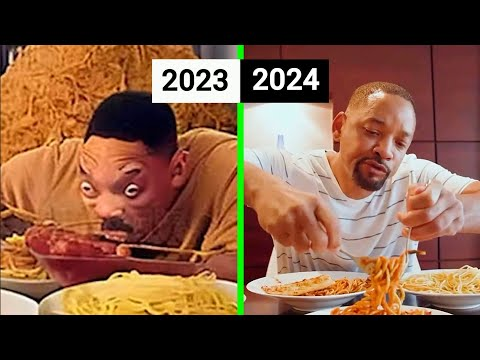

In [9]:
IPython.display.YouTubeVideo('vbWe5k4fFWE')

In [10]:
for i in df.columns:
    df.fillna({i:df[i].mean()},inplace=True)

In [11]:
df

,0,1,2,3,4
0,4,37.00,88.000000,30.0,92.000000
1,86,2.00,89.333333,66.0,87.333333
2,82,91.00,96.000000,71.0,87.333333
3,54,57.25,89.333333,94.0,98.000000
4,18,99.00,84.000000,94.0,72.000000


In [12]:
ayush = pd.DataFrame({'A':[1,1,1,1,1,1,1,2,2,2,2,3,3,3,3]})

In [13]:
ayush['A'].mode()

0    1
Name: A, dtype: int64

In [14]:
ayush

,A
0,1
1,1
2,1
3,1
4,1
5,1
6,1
7,2
8,2
9,2


In [15]:
import csv

In [16]:
#pd.read_csv(path,na_filter=)

In [17]:
#feature engineering
#feature scalling

In [18]:
#textual data to numerical data
#not imp columns
#feature of feature corelation
#feature scaling to reduce all feature at same scale

In [19]:
data = {'city':['noida','delhi','gurugram','goutambuddha','jaipur'],
        'furnished_status':['semi','fully','non','semi','non'],
        'Bedroom':np.random.randint(1,4,5),
        'Price':np.random.randint(300000,500000,5)}
house = pd.DataFrame(data)
house

,city,furnished_status,Bedroom,Price
0,noida,semi,2,427628
1,delhi,fully,1,437402
2,gurugram,non,2,437139
3,goutambuddha,semi,3,327094
4,jaipur,non,2,372390


In [20]:
#textual to numerical :- feature engineering

In [21]:
#0,1 is called sparse matrix

In [22]:
pd.get_dummies(house['city'],dtype = int)

,delhi,goutambuddha,gurugram,jaipur,noida
0,0,0,0,0,1
1,1,0,0,0,0
2,0,0,1,0,0
3,0,1,0,0,0
4,0,0,0,1,0


In [23]:
dummy_df =pd.get_dummies(house['city'],dtype = int,drop_first=True)

In [24]:
pd.concat([house,dummy_df],axis=1)

,city,furnished_status,Bedroom,Price,goutambuddha,gurugram,jaipur,noida
0,noida,semi,2,427628,0,0,0,1
1,delhi,fully,1,437402,0,0,0,0
2,gurugram,non,2,437139,0,1,0,0
3,goutambuddha,semi,3,327094,1,0,0,0
4,jaipur,non,2,372390,0,0,1,0


In [25]:
house.drop('city',axis=1,inplace=True)

In [26]:
house

,furnished_status,Bedroom,Price
0,semi,2,427628
1,fully,1,437402
2,non,2,437139
3,semi,3,327094
4,non,2,372390


In [27]:
pd.get_dummies(house['furnished_status'],dtype = int,drop_first=True)


,non,semi
0,0,1
1,0,0
2,1,0
3,0,1
4,1,0


In [28]:
house =pd.concat([pd.get_dummies(house['furnished_status'],dtype = int,drop_first=True),house],axis=1)


In [38]:
house.drop('furnished_status',axis=1,inplace=True
          )

In [39]:
house

,Bedroom,Price
0,1,411112
1,3,437039
2,3,376469
3,3,492543
4,2,320470


In [31]:
data = {'city':['greater noida','newdelhi','gurgaon','greater noida','jabalpur'],
        'furnished_status':['semi','fully','non','semi','non'],
        'Bedroom':np.random.randint(1,4,5),
        'Price':np.random.randint(300000,500000,5)}
house = pd.DataFrame(data)
house

,city,furnished_status,Bedroom,Price
0,greater noida,semi,1,411112
1,newdelhi,fully,3,437039
2,gurgaon,non,3,376469
3,greater noida,semi,3,492543
4,jabalpur,non,2,320470


In [32]:
from sklearn.preprocessing import OneHotEncoder

In [33]:
ohe = OneHotEncoder()

In [34]:
pd.DataFrame(ohe.fit_transform(house[['city']]).toarray(),columns=house['city'].unique())

,greater noida,newdelhi,gurgaon,jabalpur
0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0


In [35]:
ohe_encode_data = pd.DataFrame(ohe.fit_transform(house[['city']]).toarray(),columns=house['city'].unique())

In [36]:
house.drop('city',axis=1,inplace=True)

In [37]:
pd.concat([ohe_encode_data,house],axis=1)

,greater noida,newdelhi,gurgaon,jabalpur,furnished_status,Bedroom,Price
0,1.0,0.0,0.0,0.0,semi,1,411112
1,0.0,0.0,0.0,1.0,fully,3,437039
2,0.0,1.0,0.0,0.0,non,3,376469
3,1.0,0.0,0.0,0.0,semi,3,492543
4,0.0,0.0,1.0,0.0,non,2,320470
